### Clasificación con Naive Bayes

#1-Importación de datos

In [30]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

##Defino la raíz del sistema de archivos
raíz = "/content/drive/MyDrive/EAFIT"

## Importo el archivo
solicitantes = pd.read_excel(raíz+"/0. SolicitantesCrédito2.xlsx")
solicitantes.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tip

#2-Limpieza de datos

In [31]:
solicitantes.shape

(8378, 35)

In [32]:
### Elimino las filas donde "PreApr" está vacío
XD=solicitantes.dropna(subset=["PreApr"])

In [33]:
## Escojo las variables:Edad, Hijos, Personas a Cargo, Estrato, Ingresos, Egresos, Monto, Plazo y Cuota
XD=XD[["Edad","Hijos","Perscargo", "Estrato", "Ingresos","Egresos","Monto (EAD)", "Plazo", "Cuota (COP)"]]
XD

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,5424576,7585302,2.815030e+06,48,82691.506204
1,51,6,1,4,1144064,1640079,6.301439e+05,36,22781.212598
2,37,2,0,3,2069853,2831440,1.280540e+06,36,46294.596244
3,29,1,0,2,1893080,2482276,1.393414e+06,24,69564.950015
4,42,3,4,2,3000367,3630221,2.252986e+06,24,112478.307883
...,...,...,...,...,...,...,...,...,...
8371,48,0,0,3,4831392,3392105,3.366188e+06,36,121695.762156
8373,31,2,0,5,5891088,4292158,3.918572e+06,48,115108.056436
8374,38,0,0,3,3092079,3028098,2.677266e+06,36,96789.562091
8375,43,1,2,2,2542007,3513112,1.375112e+06,36,49713.608249


In [34]:
XD.head(10)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,38,1,0,3,5424576,7585302,2.815030e+06,48,82691.506204
1,51,6,1,4,1144064,1640079,6.301439e+05,36,22781.212598
2,37,2,0,3,2069853,2831440,1.280540e+06,36,46294.596244
3,29,1,0,2,1893080,2482276,1.393414e+06,24,69564.950015
4,42,3,4,2,3000367,3630221,2.252986e+06,24,112478.307883
5,50,1,1,2,1957244,1900521,1.456173e+06,36,52644.131911
8,29,2,0,2,1114320,974703,1.072595e+06,18,68437.780632
9,42,0,0,5,2177515,2264288,2.262295e+06,36,81787.391384
10,64,1,1,2,1498127,1176843,1.600289e+06,36,57854.278715
12,25,0,2,3,1141254,915027,8.982021e+05,36,32472.159132


In [35]:
##Escogemos la variable dependiente
yd=solicitantes["PreApr"].dropna()

#3. Implementación del modelo de Naive Bayes

In [36]:
## Importo las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.naive_bayes import GaussianNB

In [37]:
# Convierto los datasets a arrays
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [38]:
## Entreno el modelo
modelNB = GaussianNB()
modelNB.fit(XDArray, ydArray)

GaussianNB()

In [39]:
##Solicito al modelo que me prediga las yd
ydPred = modelNB.predict(XDArray)

#4. Matriz de confusión

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [41]:
cm=confusion_matrix(ydArray,ydPred)
cm

array([[2539,  420],
       [1041, 1842]])

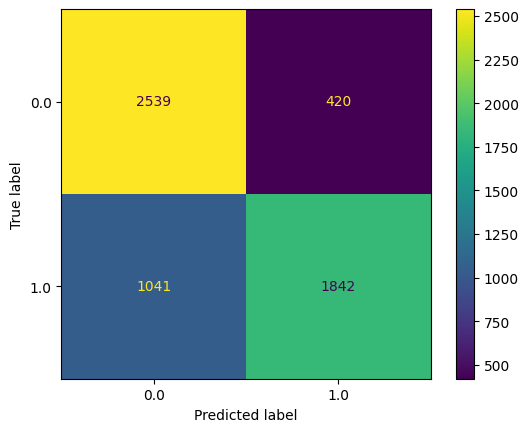

In [42]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelNB.classes_)
disp.plot()
plt.show()

**Verdaderos Positivos:** El modelo acertó al predecir que 1842 personas serían preaprobadas.
**Verdaderos Negativos:** El modelo acertó al predecir que 2539 personas no serían preaprobadas.
**Falsos Positivos:** El modelo se equivocó al predecir que 420 personas serían preaprobadas (no lo eran).
**Falsos Negativos:** El modelo se equivocó al predecir que 1041 personas no serían preaprobadas (sí lo eran).

El modelo identifica correctamente a la mayoría de los candidatos que serán aprobados (Verdaderos Positivos) y a los que no lo serán (Verdaderos Negativos). Esto es positivo, ya que reduce el riesgo de otorgar créditos a personas que no podrán pagarlos.
Por otro lado, el modelo aprueba a personas que, en realidad, no deberían ser aprobadas. Esto puede generar pérdidas económicas para la empresa, de igual forma, rechaza a personas que sí podrían pagar el crédito. Esto significa perder oportunidades de negocio.

#5. Calculamos las métricas de evaluación del modelo

In [43]:
cm

array([[2539,  420],
       [1041, 1842]])

In [44]:
#Exactitud
print(f"La exactitud del modelo es del {(cm[1][1]+ cm[0][0])/cm.sum():.2%}")
# El modelo de preaprobación de crédito ha sido capaz de predecir correctamente
# si una persona será o no preaprobada para un crédito en el 74.99% de los
# casos.

La exactitud del modelo es del 74.99%


In [45]:
#Tasa de error
print(f"La tasa de error del modelo es {(cm[1][0]+ cm[0][1])/cm.sum():.2%}")
# El modelo se equivocó al predecir si una persona sería preaprobada para un crédito
# en el 25.01% de casos.

La tasa de error del modelo es 25.01%


In [46]:
#Precisión
print(f"La precisión del modelo es del {cm[1][1]/(cm[1][1]+cm[0][1]):.2%}")
# El modelo de preaprobación de crédito ha clasificado correctamente el 81.43%
# de las instancias de datos. Esto indica que el modelo ha realizado un buen trabajo,
# pero siempre hay margen de mejora.

La precisión del modelo es del 81.43%


In [47]:
#Sensibilidad
print(f"La sensibilidad del modelo es del {cm[1][1]/(cm[1][1]+cm[1][0]):.2%}")
# Esto significa que el modelo está identificando correctamente al
# 63.89% de las personas que realmente deberían ser preaprobadas.

La sensibilidad del modelo es del 63.89%


In [48]:
#Especificidad
print(f"La especificidad  del modelo es del {cm[0][0]/(cm[0][0]+cm[0][1]):.2%}")
# Esto significa que el modelo está identificando correctamente al 85.81% de las
# personas que realmente no deberían ser preaprobadas. El modelo está identificando
# una proporción razonable de los casos negativos, pero aún hay margen de
# mejora.

La especificidad  del modelo es del 85.81%


#5. Pronóstico para preaprobación de solicitantes nuevos

In [49]:
## Filtrar solicitantes que todavía no tienen calificación
XDGener = solicitantes[solicitantes["PreApr"].isna()]
XDGener

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,2.009414e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3.563229e+03,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
11,12,46,Mujer,Casado,0,1,4,Primaria,Indefinido,7097220,...,3,1.090054e+06,Buenas Referencias,Con Codeudor(es),Prop.sin Hipoteca,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
13,14,37,Mujer,Soltero,4,2,2,Técnico,Ninguno,1791987,...,48,6.856249e+04,Buena Experiencia CFB,Sin Codeudor,Prop.sin Hipoteca,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
16,17,22,NR,Unión Libre,1,0,2,Bachiller,Fijo,2892545,...,36,6.824255e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8357,8358,24,NR,Casado,1,0,4,Técnico,Fijo,2433168,...,48,1.026380e+05,Buenas Referencias,Con Codeudor(es),Vehìculo sin Prenda,Sin experiencia,NaN,NaN,NaN,NaN
8358,8359,66,Hombre,Unión Libre,1,0,1,Técnico,Indefinido,83684,...,24,1.908509e+03,Buenas Referencias,Libranza Establecida,Sin Patrimonio,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
8367,8368,32,NR,Unión Libre,0,1,4,Bachiller,Fijo,1133063,...,36,3.665316e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
8372,8373,35,Hombre,Separado,2,1,3,Primaria,Indefinido,3073152,...,18,1.375805e+05,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [50]:
## Acotar el dataset a las columnas necesarias para generalizar
XDGener = XDGener[["Edad","Hijos","Perscargo", "Estrato", "Ingresos","Egresos","Monto (EAD)", "Plazo", "Cuota (COP)"]]
XDGener

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
6,38,3,0,3,1534711,1658694,7.913126e+05,60,2.009414e+04
7,47,0,0,2,136750,171155,1.213014e+05,48,3.563229e+03
11,46,0,1,4,7097220,9525257,3.174456e+06,3,1.090054e+06
13,37,4,2,2,1791987,1391431,2.334042e+06,48,6.856249e+04
16,22,1,0,2,2892545,3576891,1.887636e+06,36,6.824255e+04
...,...,...,...,...,...,...,...,...,...
8357,24,1,0,4,2433168,1518301,3.494059e+06,48,1.026380e+05
8358,66,1,0,1,83684,120852,3.822821e+04,24,1.908509e+03
8367,32,0,1,4,1133063,766199,1.013852e+06,36,3.665316e+04
8372,35,2,1,3,3073152,3812690,2.156239e+06,18,1.375805e+05


In [51]:
## Dataframe a array
XDGenerArray = np.array(XDGener, dtype=float)
XDGenerArray

array([[3.80000000e+01, 3.00000000e+00, 0.00000000e+00, ...,
        7.91312558e+05, 6.00000000e+01, 2.00941380e+04],
       [4.70000000e+01, 0.00000000e+00, 0.00000000e+00, ...,
        1.21301418e+05, 4.80000000e+01, 3.56322911e+03],
       [4.60000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        3.17445619e+06, 3.00000000e+00, 1.09005416e+06],
       ...,
       [3.20000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        1.01385156e+06, 3.60000000e+01, 3.66531625e+04],
       [3.50000000e+01, 2.00000000e+00, 1.00000000e+00, ...,
        2.15623904e+06, 1.80000000e+01, 1.37580518e+05],
       [2.40000000e+01, 0.00000000e+00, 0.00000000e+00, ...,
        1.90927674e+06, 3.60000000e+01, 6.90249281e+04]])

In [52]:
## Solicitar al modelo pronosticar la calificación PreApr a los solicitantes
ydGener = modelNB.predict(XDGenerArray)
ydGener

array([0., 0., 1., ..., 0., 0., 0.])

In [53]:
ydGenerSerie = pd.Series(ydGener, index=solicitantes[solicitantes["PreApr"].isna()].index)
ydGenerSerie

,0
6,0.0
7,0.0
11,1.0
13,0.0
16,0.0
17,0.0
24,0.0
27,0.0
36,1.0
41,0.0


In [54]:
solicitantes["PreApr"].fillna(ydGenerSerie, inplace=True)

In [55]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

In [56]:
solicitantes.to_excel("PronóstioPreApr.xlsx")

In [57]:
solicitantes.to_excel("/content/drive/MyDrive/PronósticoPreApr.xlsx")

**Desempeño**
El modelo de preaprobación de crédito muestra un desempeño aceptable.

Un indicador positivo es la alta especificidad (85.81%), lo que significa que el modelo identifica correctamente a la gran mayoría de los solicitantes que no deberían ser aprobados.
Por otro lado, la sensibilidad del modelo (63.89%) y la tasa de error es algo preocupante, ya que indica que el modelo podría estar rechazando a un porcentaje significativo de clientes potenciales válidos. El modelo requiere ajustes para optimizar su capacidad de identificar a todos los clientes potenciales válidos.